# Relative change analysis


## Setup


In [1]:
import glob
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymannkendall as mk

warnings.filterwarnings("ignore", category=FutureWarning)

# Paths
input_dir = Path("../input")
output_dir = Path("../output")
input_rel = input_dir / "glambie_reference"
output_rel = output_dir / "relative_change"
output_rel.mkdir(parents=True, exist_ok=True)

# Set colors
colors_list = list(plt.colormaps["tab10"].colors)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors_list)
# two colors (first two from seaborn colorblind)
blue, orange = colors_list[:2]   # first two colors

## Relative change calculations


In [2]:
glacier_mass_2000_path = input_rel / "glacier_mass_2000.csv"
calendar_years_path = input_rel / "calendar_years"

mass_2000 = pd.read_csv(str(glacier_mass_2000_path), sep=';')
file_to_mass_data = {}
for _, row in mass_2000.iterrows():
    file_to_mass_data[row['File']] = {
        'region': row['Region'],
        'mass': row['Mass'],
        'error': row['Error']
    }
annual_changes = {}

for csv_file in sorted(glob.glob(str(calendar_years_path / "*.csv"))):
    annual_changes[Path(csv_file).name] = pd.read_csv(csv_file)

In [3]:
# Calculate annual relative change with uncertainty propagation
results = []

for filename, df_changes in sorted(annual_changes.items()):
    matched_mass_data = file_to_mass_data[filename]
    current_mass = matched_mass_data['mass']
    current_mass_error = matched_mass_data['error']

    df_changes_sorted = df_changes.sort_values('start_dates').reset_index(drop=True)

    for idx, row in df_changes_sorted.iterrows():
        annual_change = row['combined_gt']
        annual_change_error = row['combined_gt_errors']

        relative_change = annual_change / current_mass

        # error propagation
        relative_change_error_term1 = (annual_change_error / annual_change) ** 2
        relative_change_error_term2 = (current_mass_error / current_mass) ** 2
        relative_change_error = abs(relative_change) * np.sqrt(relative_change_error_term1 + relative_change_error_term2)

        results.append({
            'region': matched_mass_data['region'],
            'year_start': int(row['start_dates']),
            'year_end': int(row['end_dates']),
            'glacier_mass_at_start': current_mass,
            'glacier_mass_error_at_start': current_mass_error,
            'annual_change_gt': annual_change,
            'annual_change_error': annual_change_error,
            'relative_change': relative_change,
            'relative_change_error': relative_change_error,
            'relative_change_pct': relative_change * 100,
            'relative_change_error_pct': relative_change_error * 100
        })

        current_mass = current_mass + annual_change
        current_mass_error = np.sqrt(current_mass_error**2 + annual_change_error**2)

results_df = pd.DataFrame(results)


### Combined relative change and mass evolution

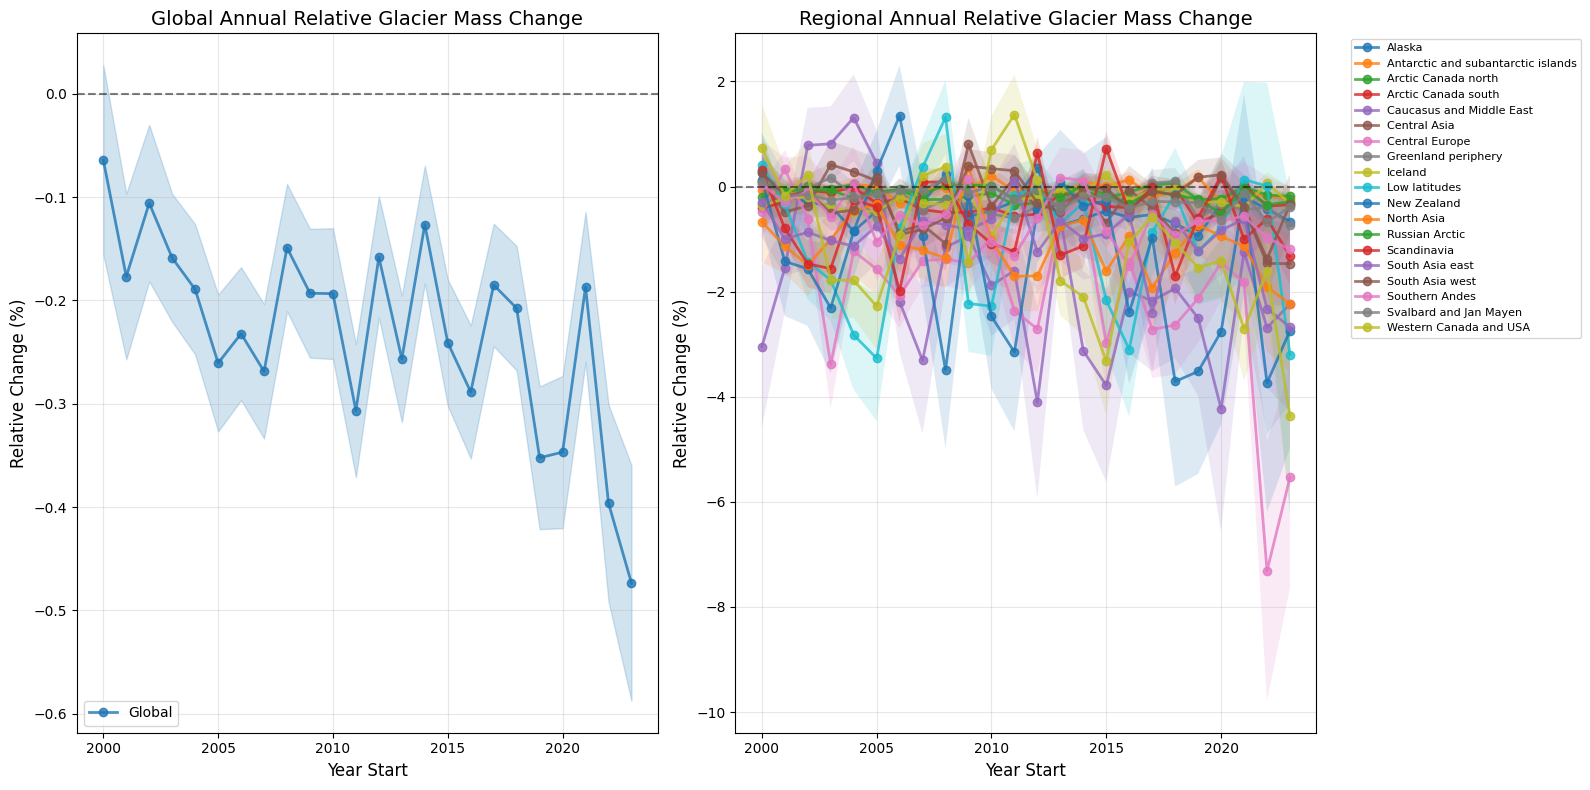

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
all_regions = sorted(results_df['region'].unique())
global_regions = [r for r in all_regions if r.lower() == 'global']
other_regions = [r for r in all_regions if r.lower() != 'global']

ax1 = axes[0]
for region in global_regions:
    region_data = results_df[results_df['region'] == region].sort_values('year_start')
    ax1.plot(region_data['year_start'], region_data['relative_change_pct'],
             marker='o', label=region, alpha=0.8, linewidth=2, color=blue)
    ax1.fill_between(region_data['year_start'],
                      region_data['relative_change_pct'] - region_data['relative_change_error_pct'],
                      region_data['relative_change_pct'] + region_data['relative_change_error_pct'],
                      alpha=0.2, color=blue)
ax1.set_xlabel('Year Start', fontsize=12)
ax1.set_ylabel('Relative Change (%)', fontsize=12)
ax1.set_title('Global Annual Relative Glacier Mass Change', fontsize=14)
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)

ax2 = axes[1]
for region in other_regions:
    region_data = results_df[results_df['region'] == region].sort_values('year_start')
    ax2.plot(region_data['year_start'], region_data['relative_change_pct'],
             marker='o', label=region, alpha=0.8, linewidth=2)
    ax2.fill_between(region_data['year_start'],
                      region_data['relative_change_pct'] - region_data['relative_change_error_pct'],
                      region_data['relative_change_pct'] + region_data['relative_change_error_pct'],
                      alpha=0.15)
ax2.set_xlabel('Year Start', fontsize=12)
ax2.set_ylabel('Relative Change (%)', fontsize=12)
ax2.set_title('Regional Annual Relative Glacier Mass Change', fontsize=14)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(output_rel / 'relative_change_plots.png', dpi=300, bbox_inches='tight')
plt.show()


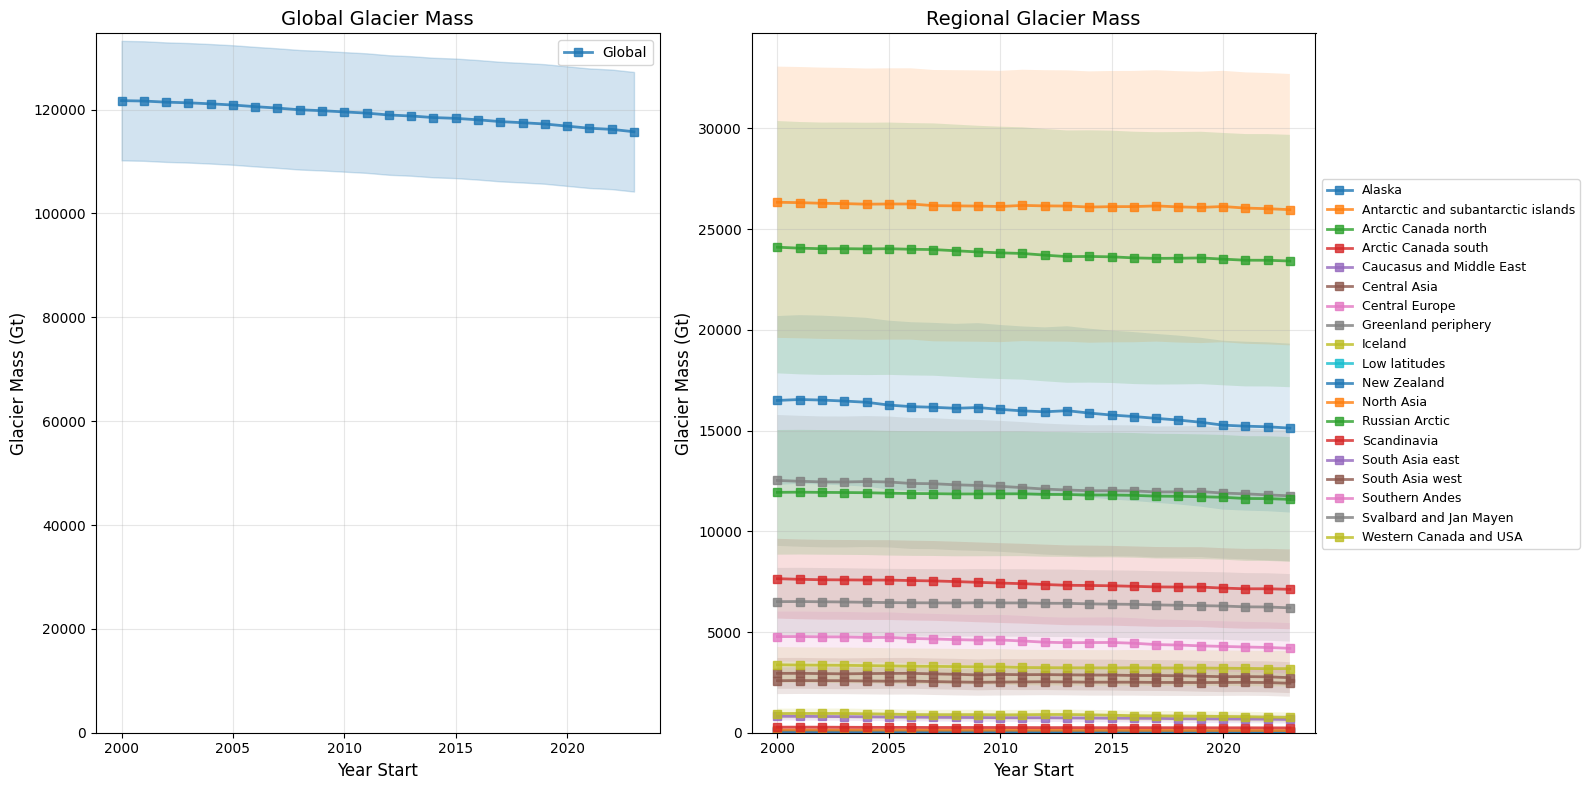

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
ax3 = axes[0]

for region in global_regions:
    region_data = results_df[results_df['region'] == region].sort_values('year_start')
    ax3.plot(region_data['year_start'], region_data['glacier_mass_at_start'],
             marker='s', label=region, alpha=0.8, linewidth=2, color=blue)
    ax3.fill_between(region_data['year_start'],
                      region_data['glacier_mass_at_start'] - region_data['glacier_mass_error_at_start'],
                      region_data['glacier_mass_at_start'] + region_data['glacier_mass_error_at_start'],
                      alpha=0.2, color=blue)
ax3.set_xlabel('Year Start', fontsize=12)
ax3.set_ylabel('Glacier Mass (Gt)', fontsize=12)
ax3.set_title('Global Glacier Mass', fontsize=14)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(bottom=0)
ax4 = axes[1]

for region in other_regions:
    region_data = results_df[results_df['region'] == region].sort_values('year_start')
    ax4.plot(region_data['year_start'], region_data['glacier_mass_at_start'],
             marker='s', label=region, alpha=0.8, linewidth=2)
    ax4.fill_between(region_data['year_start'],
                      region_data['glacier_mass_at_start'] - region_data['glacier_mass_error_at_start'],
                      region_data['glacier_mass_at_start'] + region_data['glacier_mass_error_at_start'],
                      alpha=0.15)
ax4.set_xlabel('Year Start', fontsize=12)
ax4.set_ylabel('Glacier Mass (Gt)', fontsize=12)
ax4.set_title('Regional Glacier Mass', fontsize=14)
ax4.legend(bbox_to_anchor=(1, 0.8), loc='upper left', fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(output_rel / 'glacier_mass_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

### Relative vs absolute change with trend test

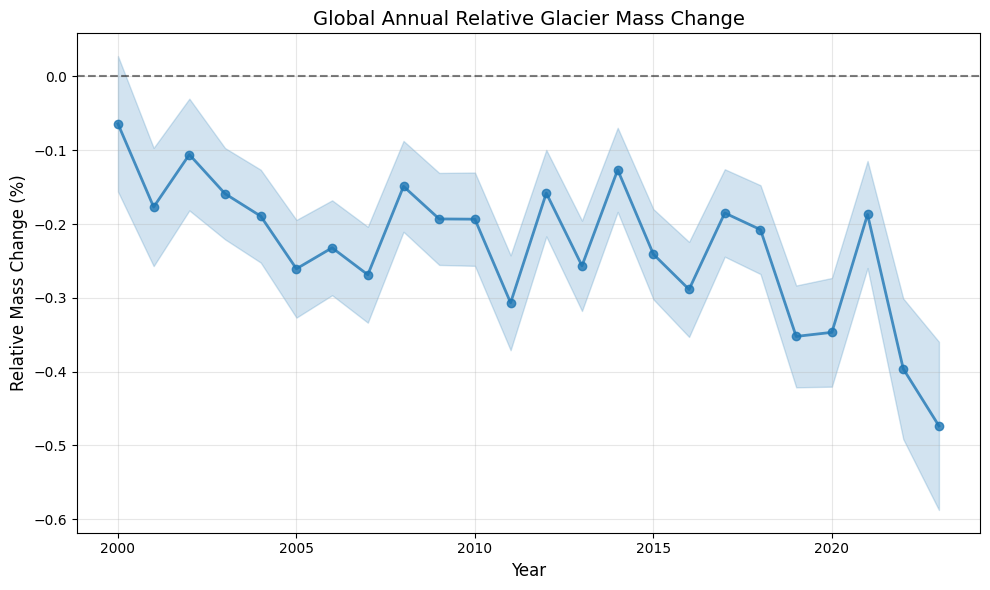

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
all_regions = sorted(results_df['region'].unique())
global_regions = [r for r in all_regions if r.lower() == 'global']
for region in global_regions:
    region_data = results_df[results_df['region'] == region].sort_values('year_start')
    ax.plot(region_data['year_start'], region_data['relative_change_pct'],
             marker='o', label=region, alpha=0.8, linewidth=2, color=blue)
    ax.fill_between(region_data['year_start'],
                    region_data['relative_change_pct'] - region_data['relative_change_error_pct'],
                    region_data['relative_change_pct'] + region_data['relative_change_error_pct'],
                    alpha=0.2, color=blue)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Relative Mass Change (%)', fontsize=12)
ax.set_title('Global Annual Relative Glacier Mass Change', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(output_rel / 'global_relative_change_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
for region in all_regions:
    region_data = results_df[results_df['region'] == region].sort_values('year_start')
    absolute_result = mk.original_test(region_data['relative_change_pct'])
    print(f"{region}: {absolute_result}")

Alaska: Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.06283881974106831), z=np.float64(-1.8603302255218441), Tau=np.float64(-0.2753623188405797), s=np.float64(-76.0), var_s=1625.3333333333333, slope=np.float64(-0.0172864443974756), intercept=np.float64(-0.24498083858822642))
Antarctic and subantarctic islands: Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.4719390404163102), z=np.float64(-0.7193276872017798), Tau=np.float64(-0.10869565217391304), s=np.float64(-30.0), var_s=1625.3333333333333, slope=np.float64(-0.003195624804964609), intercept=np.float64(-0.03935134272646619))
Arctic Canada north: Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.7098436764690532), z=np.float64(-0.37206604510436886), Tau=np.float64(-0.057971014492753624), s=np.float64(-16.0), var_s=1625.3333333333333, slope=np.float64(-0.001239827306959021), intercept=np.float64(-0.10710763342667101))
Arctic Canada south: Mann_Kendall_Test(trend='no trend', h=np.False_, p

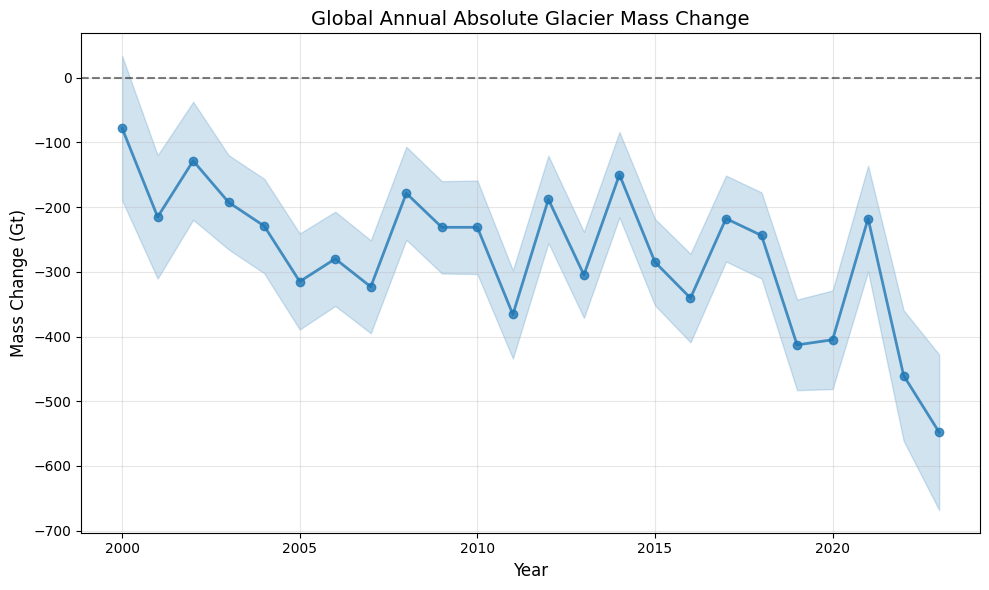

In [8]:
# Absolute change for comparison
fig, ax = plt.subplots(figsize=(10, 6))
all_regions = sorted(results_df['region'].unique())
global_regions = [r for r in all_regions if r.lower() == 'global']
for region in global_regions:
    region_data = results_df[results_df['region'] == region].sort_values('year_start')
    ax.plot(region_data['year_start'], region_data['annual_change_gt'],
             marker='o', label=region, alpha=0.8, linewidth=2, color=blue)
    ax.fill_between(region_data['year_start'],
                    region_data['annual_change_gt'] - region_data['annual_change_error'],
                    region_data['annual_change_gt'] + region_data['annual_change_error'],
                    alpha=0.2, color=blue)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mass Change (Gt)', fontsize=12)
ax.set_title('Global Annual Absolute Glacier Mass Change', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(output_rel / 'global_absolute_change_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
for region in all_regions:
    region_data = results_df[results_df['region'] == region].sort_values('year_start')
    absolute_result = mk.original_test(region_data['annual_change_gt'])
    print(f"{region}: {absolute_result}")

Alaska: Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.07821934455010537), z=np.float64(-1.7611126134940125), Tau=np.float64(-0.2608695652173913), s=np.float64(-72.0), var_s=1625.3333333333333, slope=np.float64(-2.456405379802181), intercept=np.float64(-40.87008743304646))
Antarctic and subantarctic islands: Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.5030370130775135), z=np.float64(-0.6697188811878639), Tau=np.float64(-0.10144927536231885), s=np.float64(-28.0), var_s=1625.3333333333333, slope=np.float64(-0.8266265002711259), intercept=np.float64(-10.460000608502497))
Arctic Canada north: Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.823349012100195), z=np.float64(-0.22323962706262132), Tau=np.float64(-0.036231884057971016), s=np.float64(-10.0), var_s=1625.3333333333333, slope=np.float64(-0.264160628161798), intercept=np.float64(-25.994814068836263))
Arctic Canada south: Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64

In [10]:
# Summary table: Mann-Kendall trend tests for relative and absolute change
all_regions = sorted(results_df['region'].unique())
# Put Global first, then other regions
global_first = [r for r in all_regions if r.lower() == 'global'] + [r for r in all_regions if r.lower() != 'global']

mk_summary = []
for region in global_first:
    region_data = results_df[results_df['region'] == region].sort_values('year_start')
    rel_result = mk.original_test(region_data['relative_change_pct'])
    abs_result = mk.original_test(region_data['annual_change_gt'])
    mk_summary.append({
        'Region': region,
        'Relative change p-value': round(rel_result.p, 3),
        'Relative change trend': rel_result.trend,
        'Absolute change p-value': round(abs_result.p, 3),
        'Absolute change trend': abs_result.trend,
    })

mk_summary_df = pd.DataFrame(mk_summary)
mk_summary_df

,Region,Relative change p-value,Relative change trend,Absolute change p-value,Absolute change trend
0,Global,0.002,decreasing,0.002,decreasing
1,Alaska,0.063,no trend,0.078,no trend
2,Antarctic and subantarctic islands,0.472,no trend,0.503,no trend
3,Arctic Canada north,0.710,no trend,0.823,no trend
4,Arctic Canada south,0.901,no trend,0.901,no trend
5,Caucasus and Middle East,0.031,decreasing,0.264,no trend
6,Central Asia,0.056,no trend,0.078,no trend
7,Central Europe,0.011,decreasing,0.050,no trend
8,Greenland periphery,0.206,no trend,0.286,no trend
9,Iceland,0.157,no trend,0.118,no trend


In [11]:
# Export Mann-Kendall summary for report Section 3
mk_summary_path = output_rel / "mann_kendall_summary.csv"
mk_summary_df.to_csv(mk_summary_path, index=False)
print(f"Saved: {mk_summary_path}")
mk_summary_df

Saved: ..\output\relative_change\mann_kendall_summary.csv


,Region,Relative change p-value,Relative change trend,Absolute change p-value,Absolute change trend
0,Global,0.002,decreasing,0.002,decreasing
1,Alaska,0.063,no trend,0.078,no trend
2,Antarctic and subantarctic islands,0.472,no trend,0.503,no trend
3,Arctic Canada north,0.710,no trend,0.823,no trend
4,Arctic Canada south,0.901,no trend,0.901,no trend
5,Caucasus and Middle East,0.031,decreasing,0.264,no trend
6,Central Asia,0.056,no trend,0.078,no trend
7,Central Europe,0.011,decreasing,0.050,no trend
8,Greenland periphery,0.206,no trend,0.286,no trend
9,Iceland,0.157,no trend,0.118,no trend


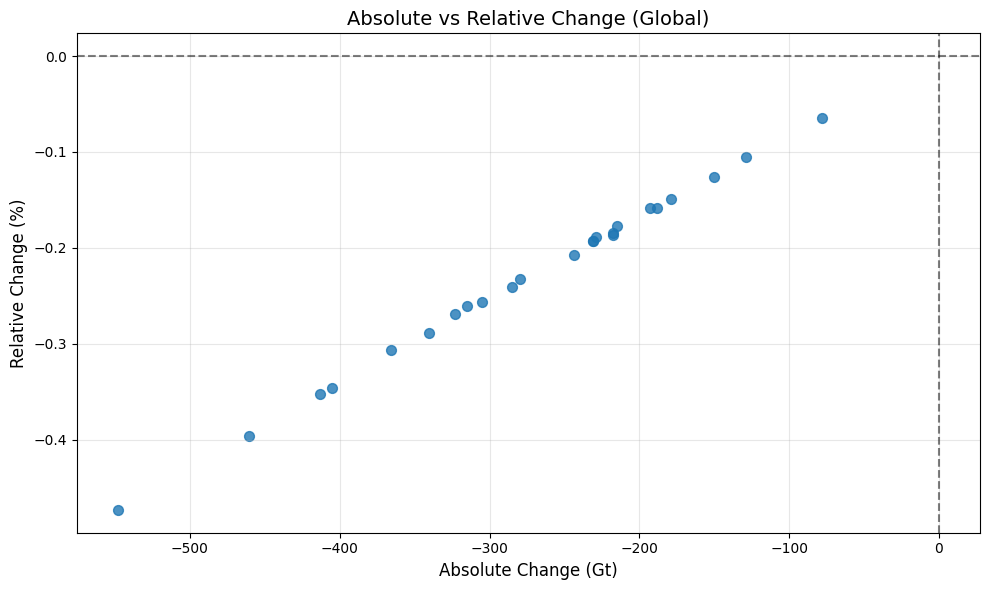

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
for region in global_regions:
    region_data = results_df[results_df['region'] == region].sort_values('year_start')
    ax.scatter(region_data['annual_change_gt'], region_data['relative_change_pct'],
               marker='o', label=region, alpha=0.8, s=50, color=blue)
ax.set_xlabel('Absolute Change (Gt)', fontsize=12)
ax.set_ylabel('Relative Change (%)', fontsize=12)
ax.set_title('Absolute vs Relative Change (Global)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(output_rel / 'absolute_vs_relative_change.png', dpi=300, bbox_inches='tight')
plt.show()


### Combined relative change and mass evolution

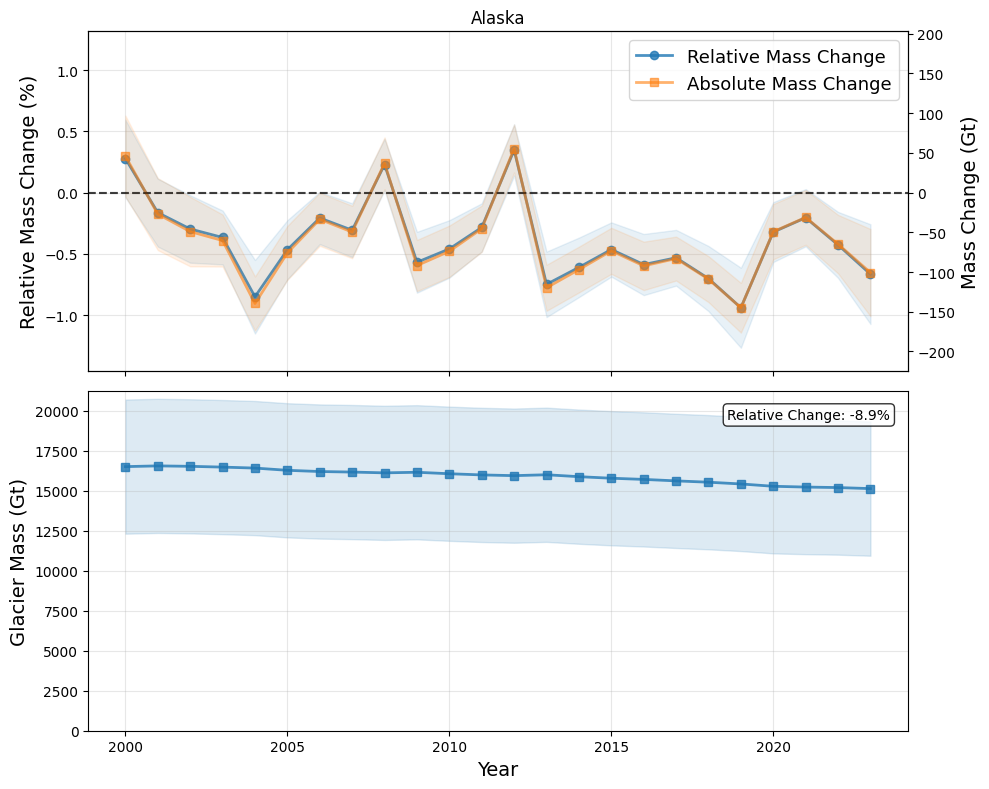

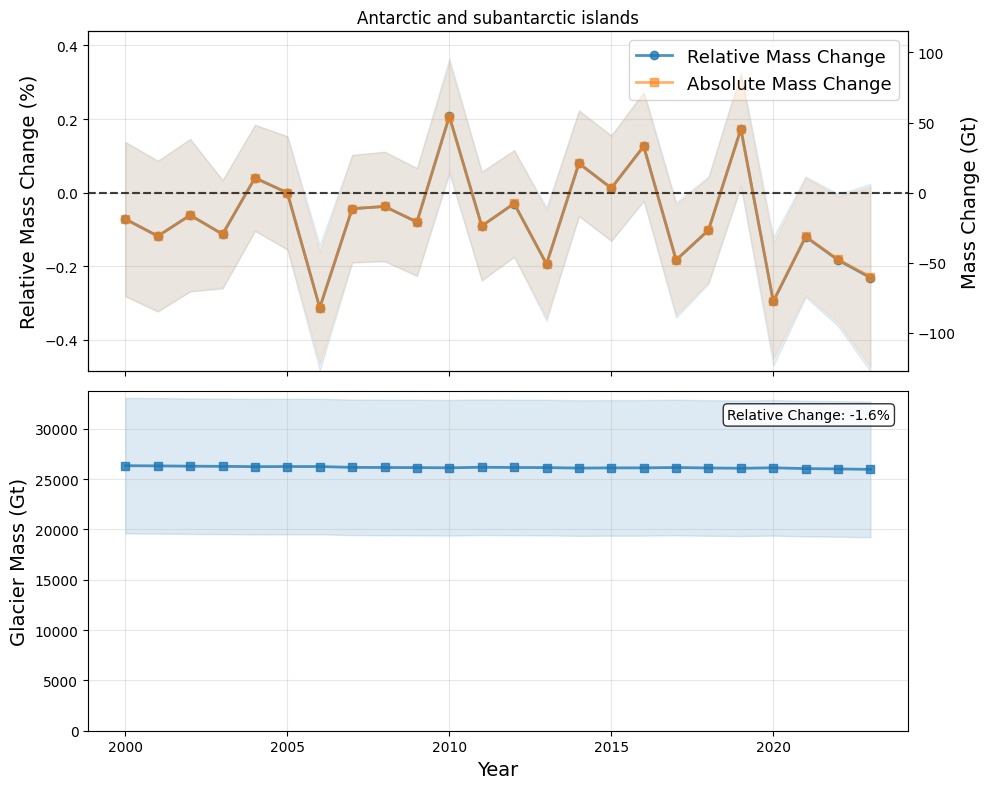

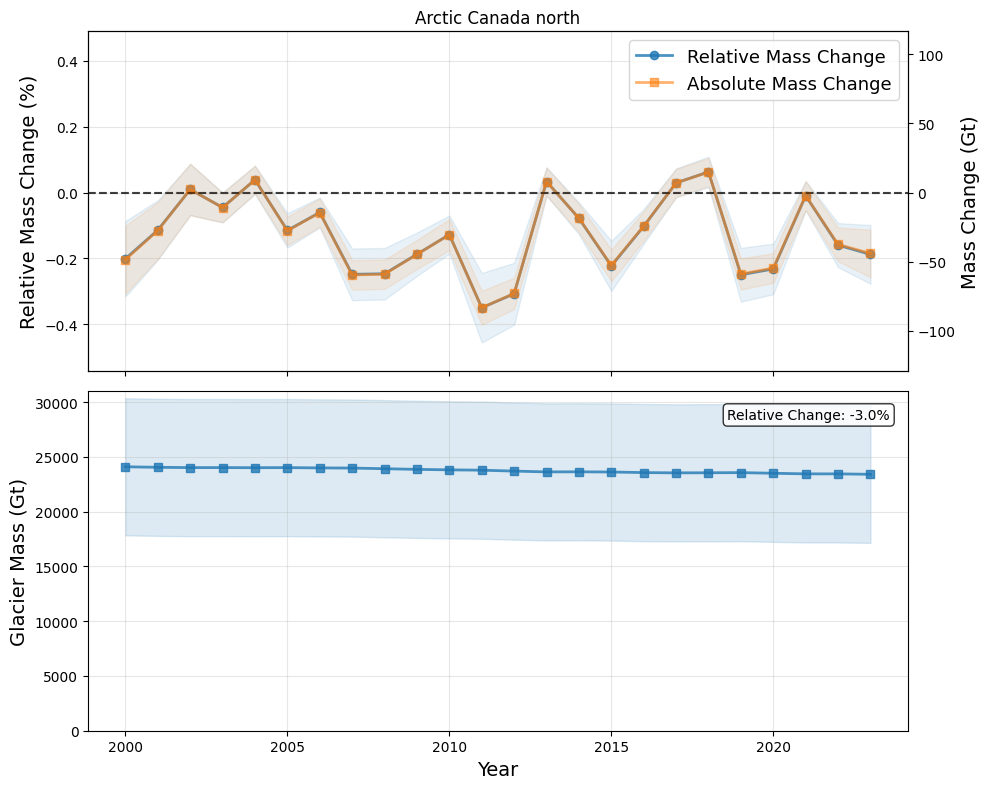

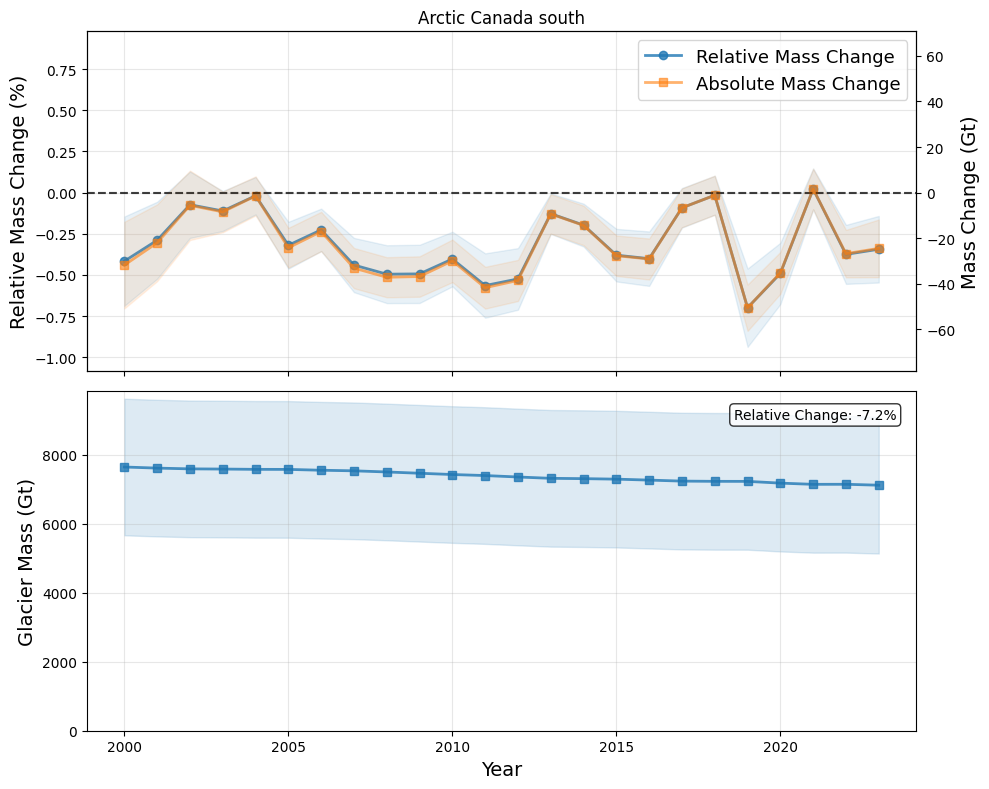

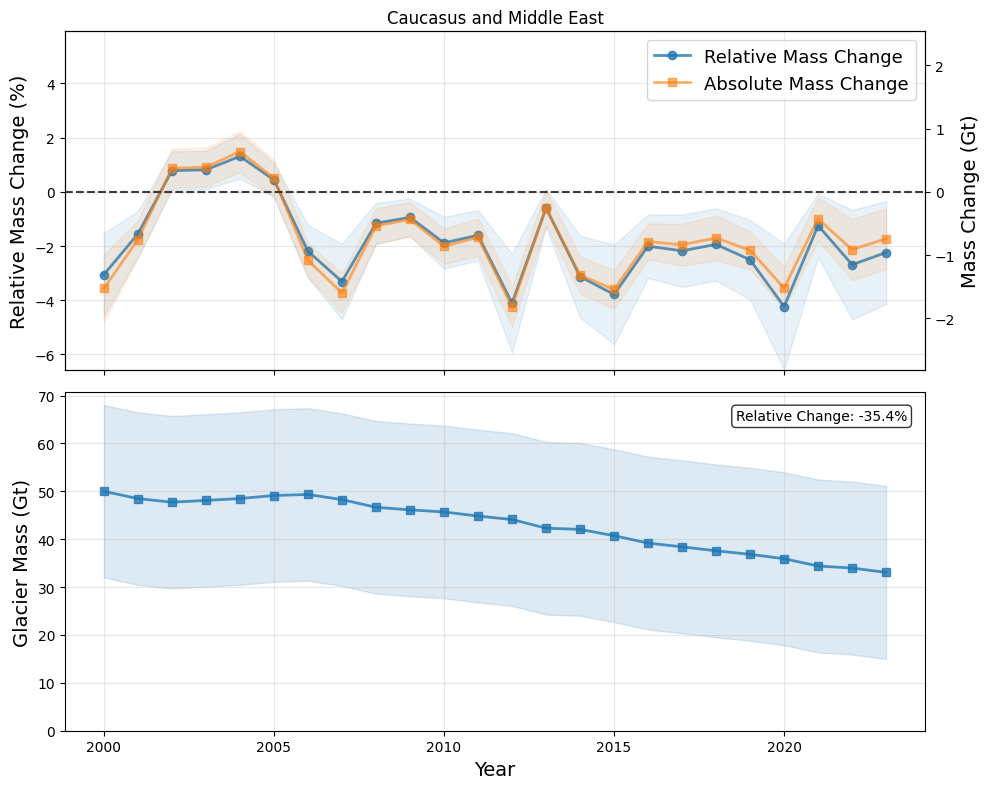

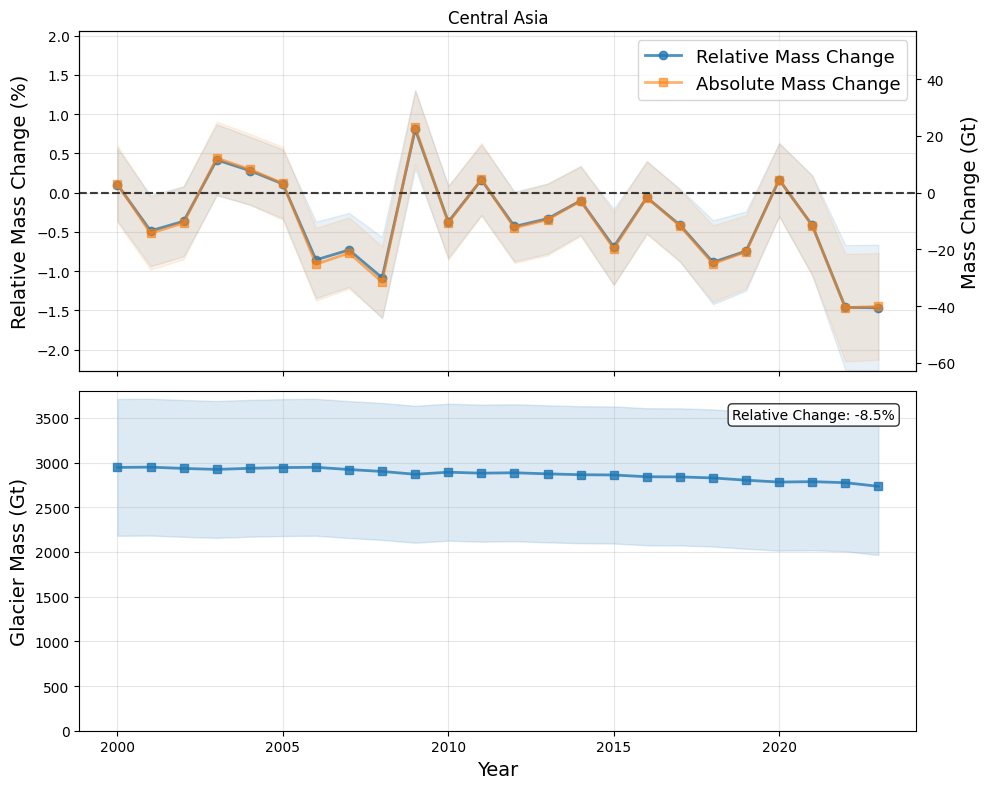

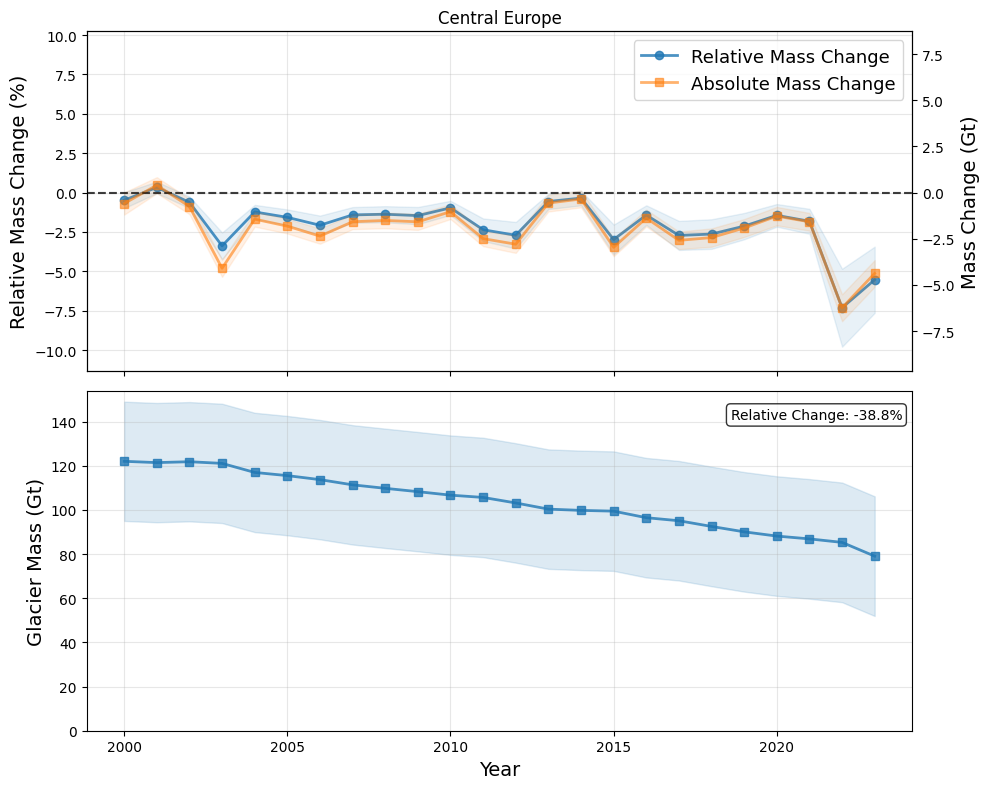

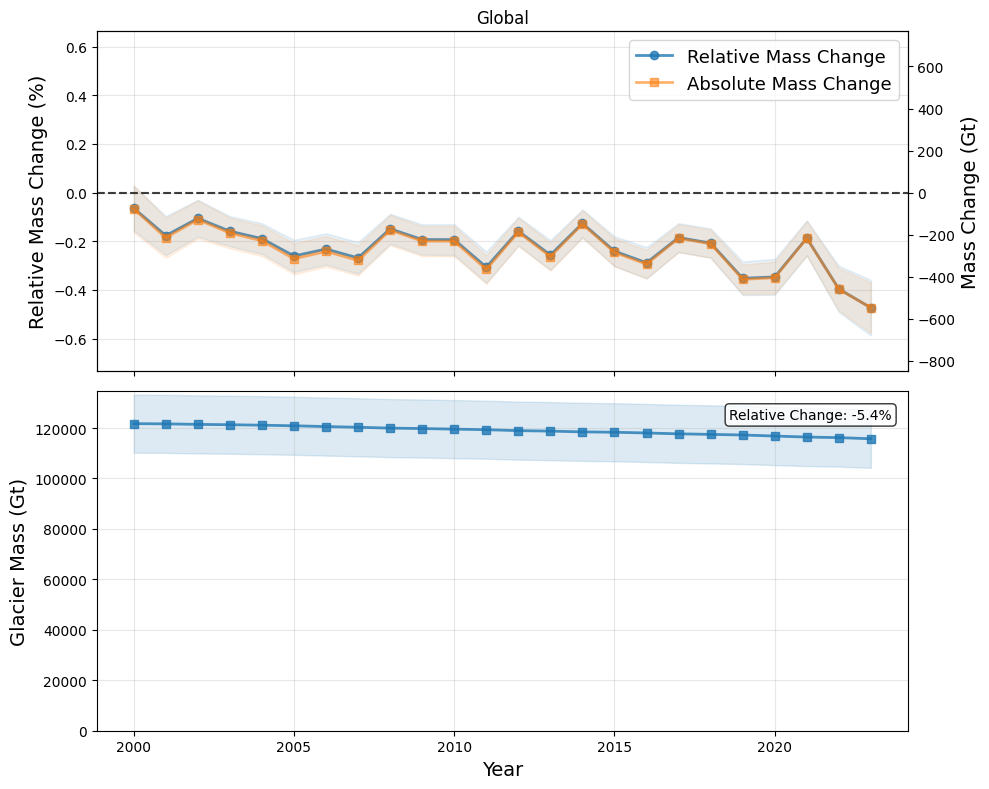

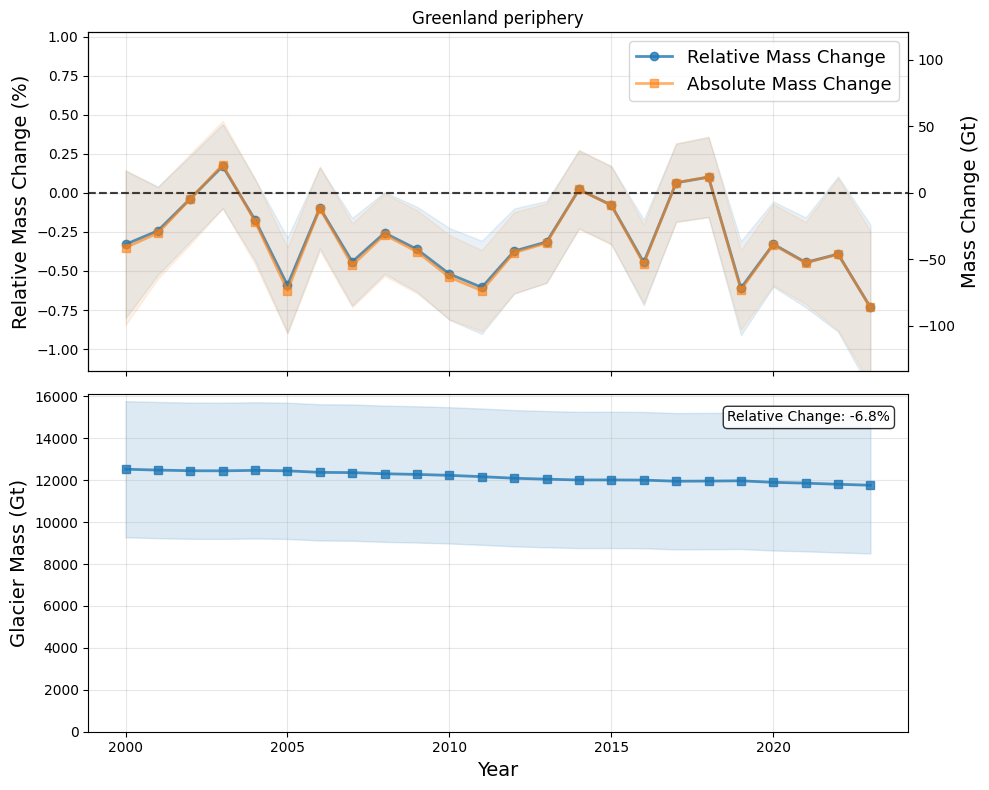

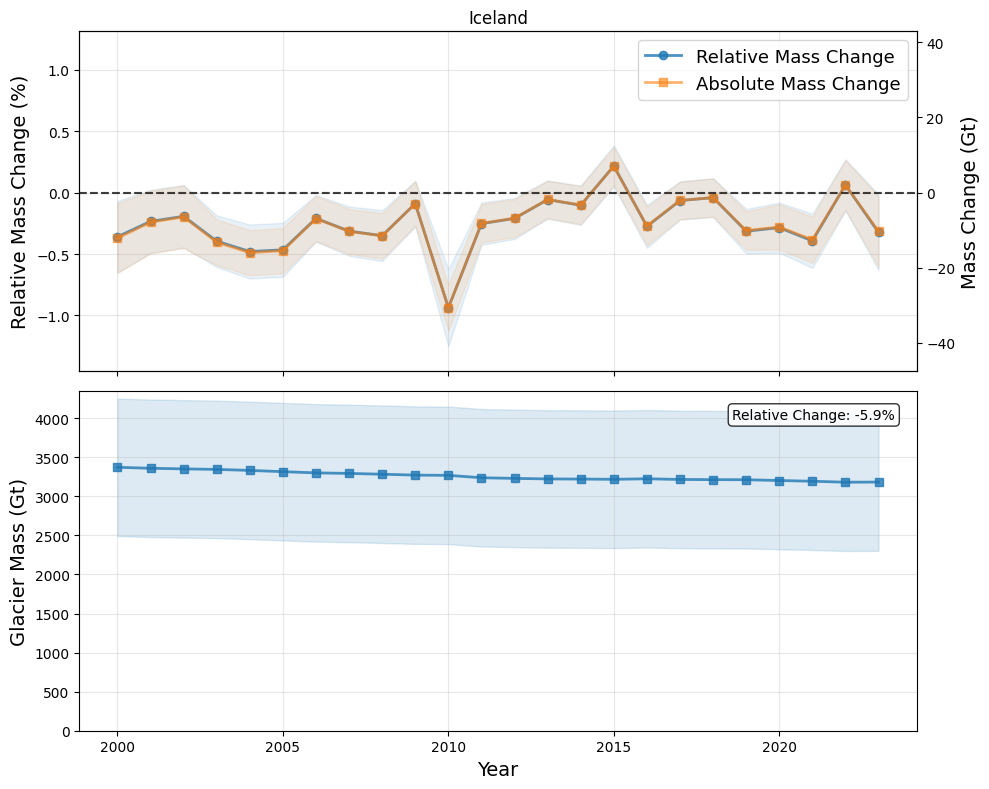

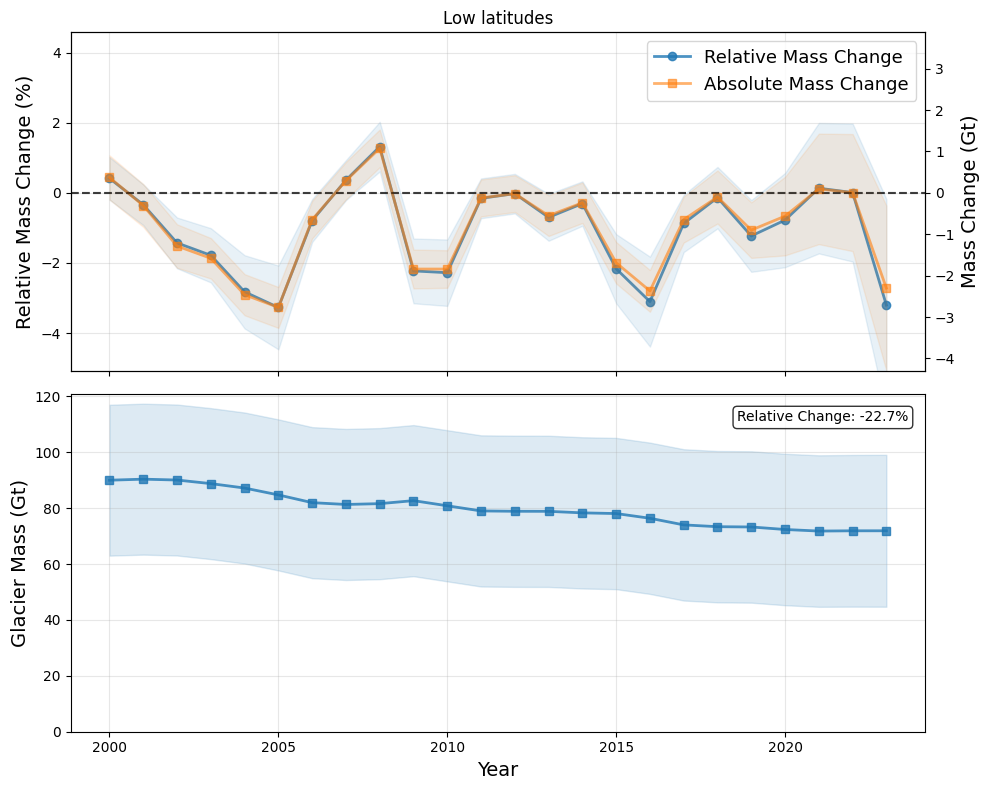

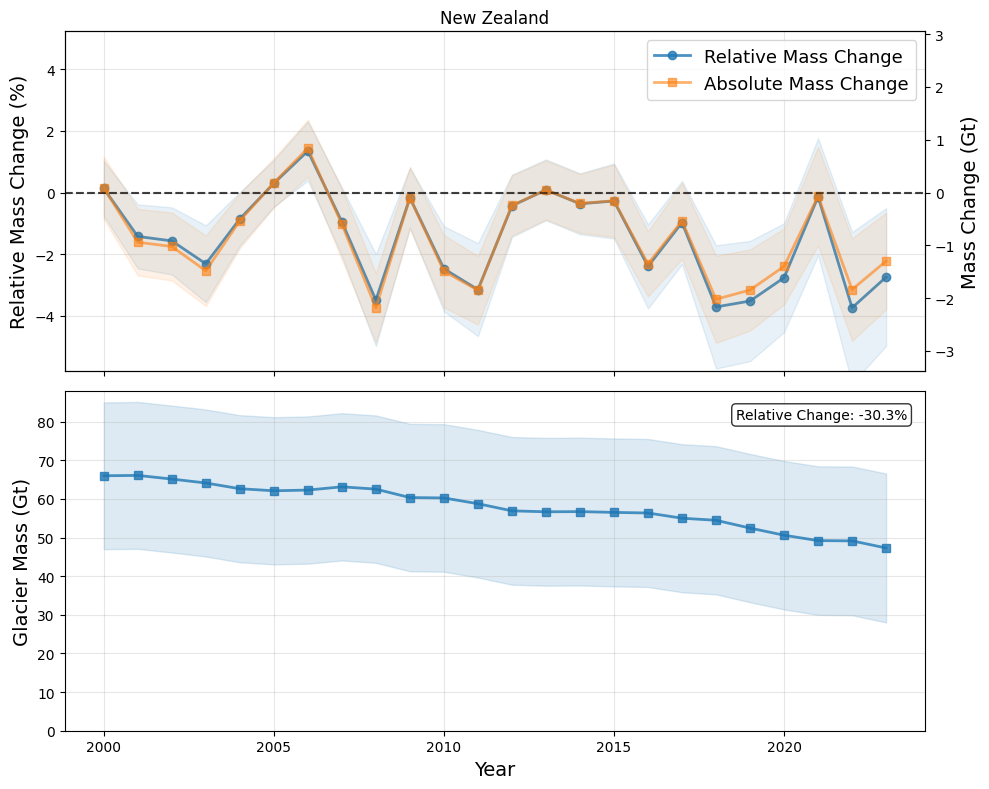

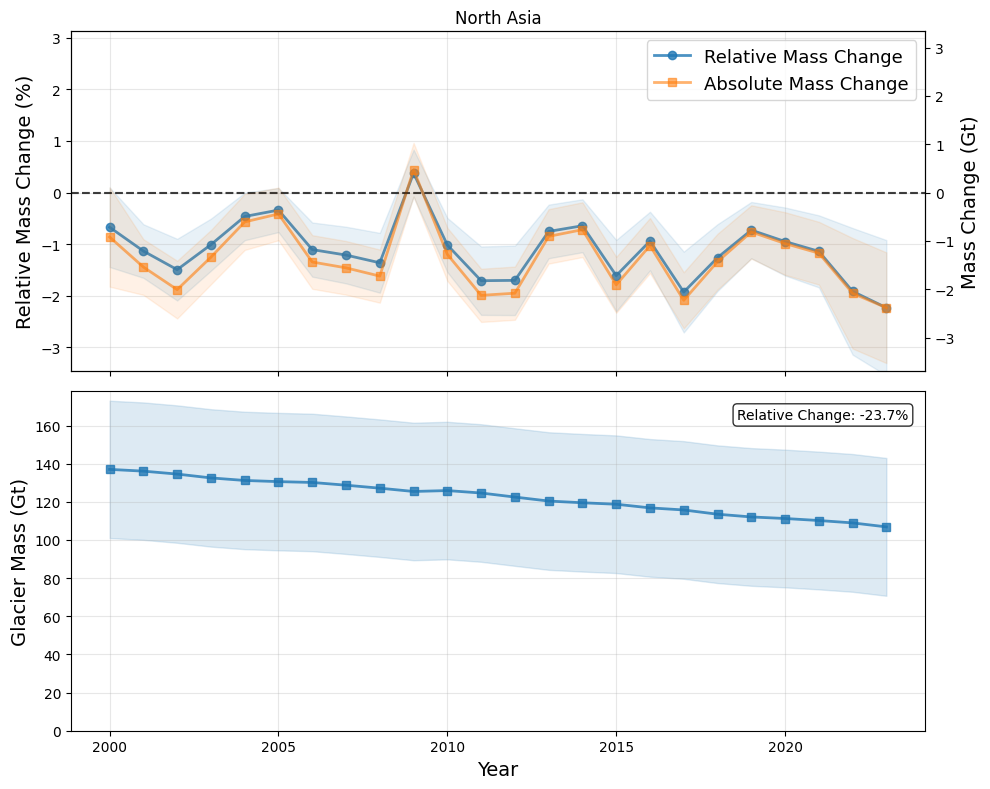

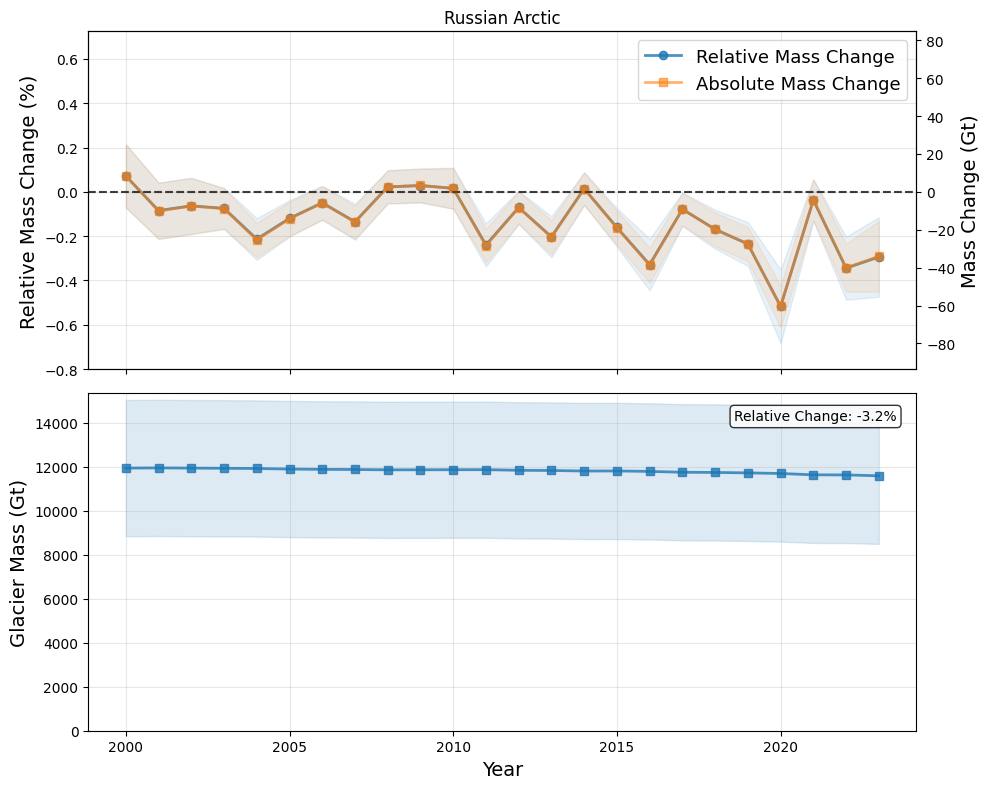

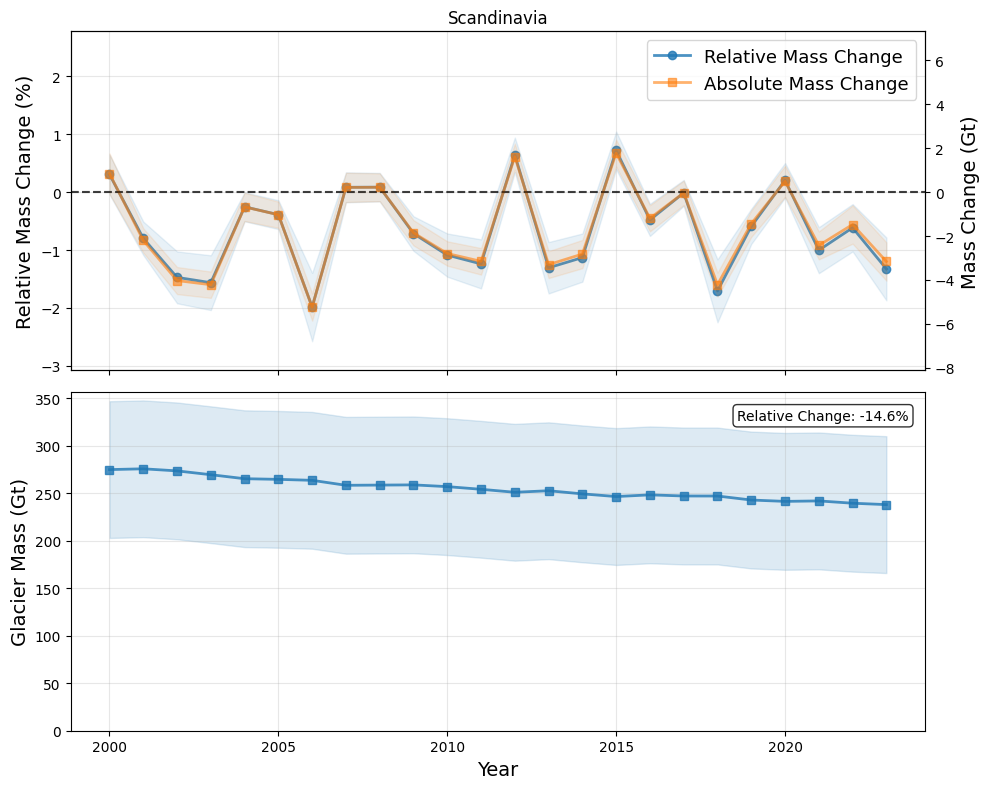

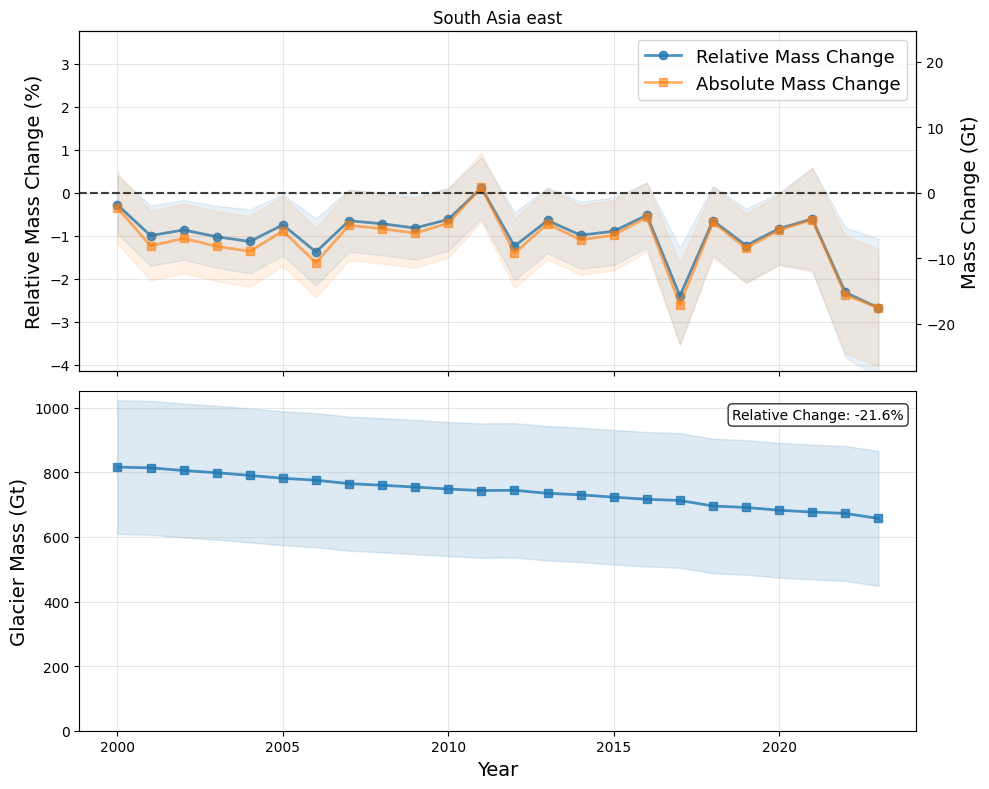

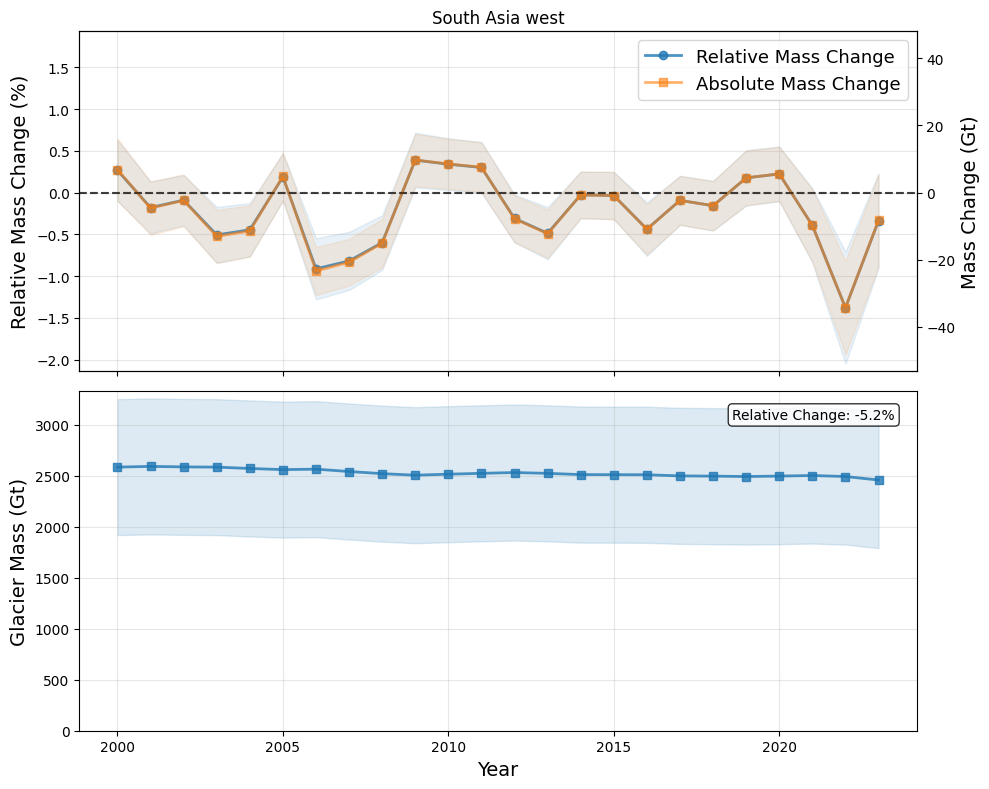

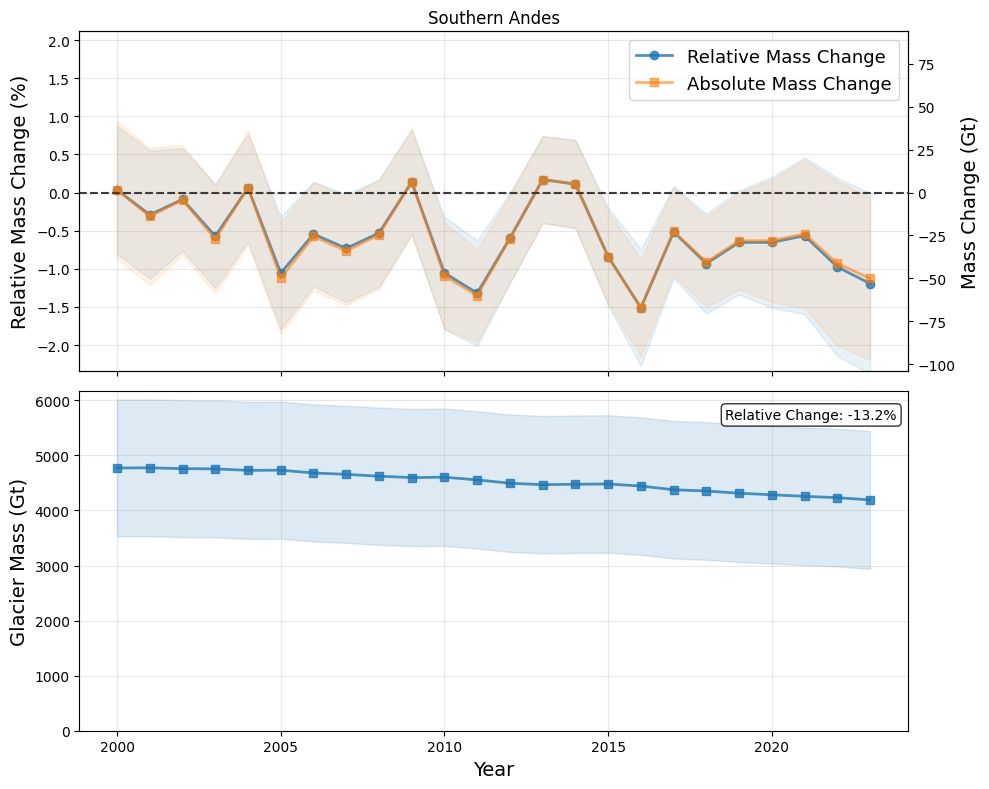

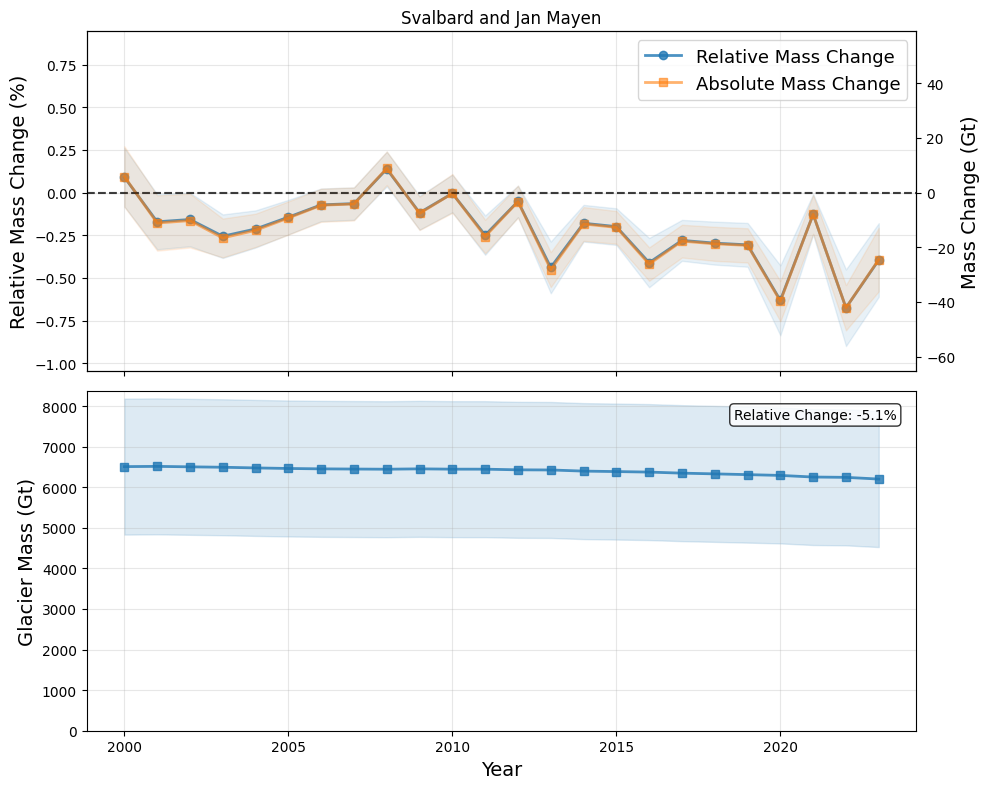

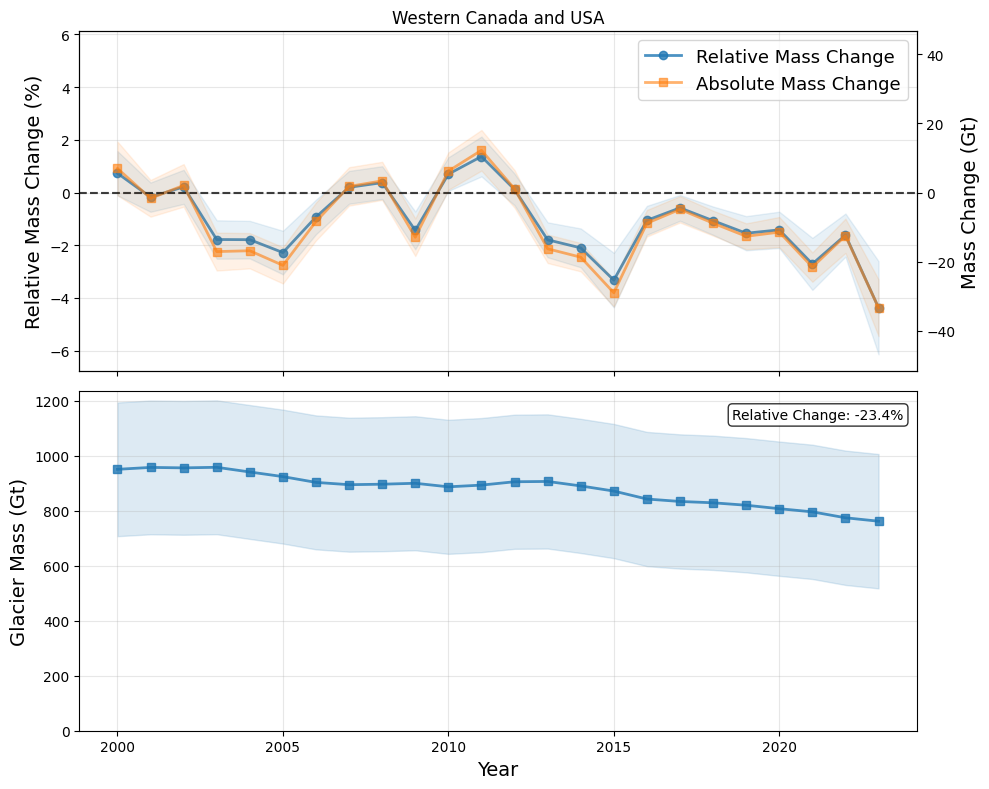

In [13]:
for region in sorted(results_df['region'].unique()):
    region_data = results_df[results_df['region'] == region].sort_values('year_start')

    # Glacier Mass Data
    x_mass = region_data['year_start'].values
    y_mass = region_data['glacier_mass_at_start'].values
    y_err_mass = region_data['glacier_mass_error_at_start'].values

    # Relative Change Data
    x_rel = region_data['year_start'].values
    y_rel = region_data['relative_change_pct'].values
    y_err_rel = region_data['relative_change_error_pct'].values

    # Compute relative change from start to end for glacier mass
    start_mass = region_data.iloc[0]['glacier_mass_at_start']
    end_mass = region_data.iloc[-1]['glacier_mass_at_start']
    relative_change = ((end_mass - start_mass) / start_mass) * 100

    # Create a figure with two subplots (top = upper, bottom = glacier mass)
    fig, (ax_top, ax_bottom) = plt.subplots(nrows=2, figsize=(10, 8), sharex=True)

    # Upper subplot: Relative change (%) + twin for Absolute change (Gt)
    ax_top.plot(x_rel, y_rel, marker='o', label='Relative Mass Change', alpha=0.8, linewidth=2, color=blue)
    ax_top.fill_between(x_rel, y_rel - y_err_rel, y_rel + y_err_rel, alpha=0.1, color=blue)
    ax_top.set_ylabel('Relative Mass Change (%)', fontsize=14)
    ax_top.set_title(f'{region}')
    ax_top.grid(True, alpha=0.3)

    # Twin axis for absolute change (Gt) # DELETE IF PLOTTING ONLY RELATIVE CHANGES
    ax_top_twin = ax_top.twinx()
    ax_top_twin.plot(region_data['year_start'], region_data['annual_change_gt'],
                     marker='s', label='Absolute Mass Change', alpha=0.6, linewidth=2, color=orange)
    ax_top_twin.fill_between(region_data['year_start'],
                             region_data['annual_change_gt'] - region_data['annual_change_error'],
                             region_data['annual_change_gt'] + region_data['annual_change_error'],
                             alpha=0.1, color=orange)
    ax_top_twin.set_ylabel('Mass Change (Gt)', fontsize=14)

    # Symmetric y-limits and zero lines for upper panel
    max_rel = max(abs(region_data['relative_change_pct'].min()), abs(region_data['relative_change_pct'].max()))
    max_abs = max(abs(region_data['annual_change_gt'].min()), abs(region_data['annual_change_gt'].max()))
    ax_top.set_ylim(-max_rel * 1.55, max_rel * 1.4)
    ax_top_twin.set_ylim(-max_abs * 1.55, max_abs * 1.4)
    ax_top.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax_top_twin.axhline(y=0, color='k', linestyle='--', alpha=0.5)

    h1, l1 = ax_top.get_legend_handles_labels()
    h2, l2 = ax_top_twin.get_legend_handles_labels()

    ax_top.legend(h1 + h2, l1 + l2, loc="upper right", frameon=True, fontsize=13)

    # Lower subplot: Glacier Mass (Gt)
    ax_bottom.plot(x_mass, y_mass, marker='s', linestyle='-', alpha=0.8, linewidth=2, color=blue)
    ax_bottom.fill_between(x_mass, y_mass - y_err_mass, y_mass + y_err_mass, alpha=0.15, color=blue)
    y_lower_mass = np.nanmin(y_mass - y_err_mass)
    y_upper_mass = np.nanmax(y_mass + y_err_mass)
    pad_mass = 0.05 * (y_upper_mass - y_lower_mass) if y_upper_mass > y_lower_mass else 1.0
    ax_bottom.set_ylim(0, y_upper_mass + pad_mass)

    start_mass = region_data.iloc[0]['glacier_mass_at_start']
    end_mass = region_data.iloc[-1]['glacier_mass_at_start'] + region_data.iloc[-1]['annual_change_gt']
    overall_relative_change = ((end_mass - start_mass) / start_mass) * 100

    ax_bottom.text(0.78, 0.95, f"Relative Change: {overall_relative_change:.1f}%",
                   transform=ax_bottom.transAxes, fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax_bottom.set_ylabel('Glacier Mass (Gt)', fontsize=14)
    ax_bottom.set_xlabel('Year', fontsize=14)
    ax_bottom.grid(alpha=0.3)

    fname = f"combined_{region.replace(' ', '_').replace('/', '_').lower()}.png"
    plt.tight_layout()
    plt.savefig(output_rel / fname, dpi=300, bbox_inches='tight')
    plt.show()